In [62]:
# read in the training, validation and test set
import pandas as pd
import bioacoustics_model_zoo as bmz
import torch

birdnet = bmz.BirdNET()
train_set = pd.read_csv('resampled_train_set.csv', index_col=[0,1,2])
val_set = pd.read_csv('validation_set.csv', index_col=[0,1,2])

downloading model from URL...


/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/opensoundscape/ml/cnn.py:599: UserWarning: 
                    This architecture is not listed in opensoundscape.ml.cnn_architectures.ARCH_DICT.
                    It will not be available for loading after saving the model with .save() (unless using pickle=True). 
                    To make it re-loadable, define a function that generates the architecture from arguments: (n_classes, n_channels) 
                    then use opensoundscape.ml.cnn_architectures.register_architecture() to register the generating function.

                    The function can also set the returned object's .constructor_name to the registered string key in ARCH_DICT
                    to avoid this warning and ensure it is reloaded correctly by opensoundscape.ml.load_model().

                    See opensoundscape.ml.cnn_architectures module for examples of constructor functions
                    
  warnings.warn(
/home/She

In [38]:
train_set

Cheer  \
file                                               start_time end_time          
/mnt/class_data/Shelby/One_Minute_Audio/SL10_Tr... 33.0       36.0       True   
/mnt/class_data/Shelby/One_Minute_Audio/SL51_Tr... 48.0       51.0       True   
/mnt/class_data/Shelby/One_Minute_Audio/SL42_Tr... 51.0       54.0       True   
/mnt/class_data/Shelby/One_Minute_Audio/SL10_Tr... 45.0       48.0       True   
/mnt/class_data/Shelby/One_Minute_Audio/SL09_Tr... 39.0       42.0       True   
...                                                                       ...   
/mnt/class_data/Shelby/One_Minute_Audio/SL50_Tr... 42.0       45.0      False   
/mnt/class_data/Shelby/One_Minute_Audio/SL36_Tr... 18.0       21.0      False   
                                                   24.0       27.0      False   
                                                   27.0       30.0      False   
                                                   54.0       57.0      False   

                                                                            A  \
file                                               start_time end_time          
/mnt/class_data/Shelby/One_Minute_Audio/SL10_Tr... 33.0       36.0      False   
/mnt/class_data/Shelby/One_Minute_Audio/SL51_Tr... 48.0       51.0      False   
/mnt/class_data/Shelby/One_Minute_Audio/SL42_Tr... 51.0       54.0      False   
/mnt/class_data/Shelby/One_Minute_Audio/SL10_Tr... 45.0       48.0      False   
/mnt/class_data/Shelby/One_Minute_Audio/SL09_Tr... 39.0       42.0      False   
...                                                                       ...   
/mnt/class_data/Shelby/One_Minute_Audio/SL50_Tr... 42.0       45.0      False   
/mnt/class_data/Shelby/One_Minute_Audio/SL36_Tr... 18.0       21.0      False   
                                                   24.0       27.0      False   
                                                   27.0       30.0      False   
                                                   54.0       57.0      False   

                                                                        Check  \
file                                               start_time end_time          
/mnt/class_data/Shelby/One_Minute_Audio/SL10_Tr... 33.0       36.0      False   
/mnt/class_data/Shelby/One_Minute_Audio/SL51_Tr... 48.0       51.0      False   
/mnt/class_data/Shelby/One_Minute_Audio/SL42_Tr... 51.0       54.0       True   
/mnt/class_data/Shelby/One_Minute_Audio/SL10_Tr... 45.0       48.0      False   
/mnt/class_data/Shelby/One_Minute_Audio/SL09_Tr... 39.0       42.0      False   
...                                                                       ...   
/mnt/class_data/Shelby/One_Minute_Audio/SL50_Tr... 42.0       45.0       True   
/mnt/class_data/Shelby/One_Minute_Audio/SL36_Tr... 18.0       21.0      False   
                                                   24.0       27.0      False   
                                                   27.0       30.0      False   
                                                   54.0       57.0      False   

                                                                            B  \
file                                               start_time end_time          
/mnt/class_data/Shelby/One_Minute_Audio/SL10_Tr... 33.0       36.0      False   
/mnt/class_data/Shelby/One_Minute_Audio/SL51_Tr... 48.0       51.0      False   
/mnt/class_data/Shelby/One_Minute_Audio/SL42_Tr... 51.0       54.0      False   
/mnt/class_data/Shelby/One_Minute_Audio/SL10_Tr... 45.0       48.0      False   
/mnt/class_data/Shelby/One_Minute_Audio/SL09_Tr... 39.0       42.0      False   
...                                                                       ...   
/mnt/class_data/Shelby/One_Minute_Audio/SL50_Tr... 42.0       45.0      False   
/mnt/class_data/Shelby/One_Minute_Audio/SL36_Tr... 18.0       21.0      False   
                                                   24.0       27.0      False   
                   

In [63]:
emb_train = birdnet.embed(train_set, return_dfs=False, batch_size=128, num_workers=0)
emb_val = birdnet.embed(val_set, return_dfs=False, batch_size=128, num_workers=0)

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

In [67]:
# We want to train the classifier on the 'A' class here, corresponding to the primary R. sierrae call type.
# Let's replace fc output layer with 1-output layer for class 'A'
classes = list(train_set.columns)
birdnet.change_classes(classes)

# fit the classification head with embeddings and labels
birdnet.network.fit(emb_train, train_set.values, emb_val, val_set.values)


Epoch 100/1000, Loss: 0.05854833126068115, Val Loss: 0.14540651440620422
val AU ROC: nan
val MAP: 0.416
Epoch 200/1000, Loss: 0.022541673853993416, Val Loss: 0.14326968789100647
val AU ROC: nan
val MAP: 0.445


/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442:

Epoch 300/1000, Loss: 0.012356650084257126, Val Loss: 0.14779163897037506
val AU ROC: nan
val MAP: 0.446
Epoch 400/1000, Loss: 0.007977472618222237, Val Loss: 0.15280112624168396
val AU ROC: nan
val MAP: 0.450


/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442:

Epoch 500/1000, Loss: 0.005649580620229244, Val Loss: 0.15748216211795807
val AU ROC: nan
val MAP: 0.451
Epoch 600/1000, Loss: 0.004245143849402666, Val Loss: 0.16174107789993286
val AU ROC: nan
val MAP: 0.451


/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442:

Epoch 700/1000, Loss: 0.0033235854934901, Val Loss: 0.1656140387058258
val AU ROC: nan
val MAP: 0.452
Epoch 800/1000, Loss: 0.0026816418394446373, Val Loss: 0.16915667057037354
val AU ROC: nan
val MAP: 0.452


/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442:

Epoch 900/1000, Loss: 0.0022140038199722767, Val Loss: 0.1724204272031784
val AU ROC: nan
val MAP: 0.452
Epoch 1000/1000, Loss: 0.0018613083520904183, Val Loss: 0.17544837296009064
val AU ROC: nan
val MAP: 0.452
Training complete


/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442:

In [93]:
birdnet = bmz.BirdNET()

downloading model from URL...


/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/opensoundscape/ml/cnn.py:599: UserWarning: 
                    This architecture is not listed in opensoundscape.ml.cnn_architectures.ARCH_DICT.
                    It will not be available for loading after saving the model with .save() (unless using pickle=True). 
                    To make it re-loadable, define a function that generates the architecture from arguments: (n_classes, n_channels) 
                    then use opensoundscape.ml.cnn_architectures.register_architecture() to register the generating function.

                    The function can also set the returned object's .constructor_name to the registered string key in ARCH_DICT
                    to avoid this warning and ensure it is reloaded correctly by opensoundscape.ml.load_model().

                    See opensoundscape.ml.cnn_architectures module for examples of constructor functions
                    
  warnings.warn(
/home/She

In [96]:
?birdnet.initialize_custom_classifier

Signature: birdnet.initialize_custom_classifier(new_classes, hidden_layer_sizes=())
Docstring:
initialize a custom classifier to replace the BirdNET classifier head

The classifier is a multi-layer perceptron with ReLU activations and a final
linear layer. The input size is the size of the embeddings from the BirdNET model,
and the output size is the number of classes.

The new classifier (self.network) will have random weights, and can be trained with
self.train().

Sets self.use_custom_classifier = True, so that predict() returns outputs from the
custom classifier rather than from the original TF model classification head.
Set .use_custom_classifier=False if you want predict to return the original
model's classification logits.

Args:
    hidden_layer_sizes: tuple of int, sizes of hidden layers in the classifier
        [default: ()]
    classes: list of str, class names for the classifier. Will run self.change_classes(classes)
        if not None. If None, uses self.classes. [defaul

In [ ]:
# num_workers=0
# birdnet.initialize_custom_classifier(classes=classes)

# num_workers=0
birdnet.change_classes(classes)


In [102]:
birdnet.train(
    train_df=train_set,
    validation_df=val_set,
    embedding_batch_size=128,
    embedding_num_workers=4,
    n_augmentation_variants=2,
    steps=250,
)

Embedding the training samples 2 times with stochastic augmentation


  0%|          | 0/2 [00:00<?, ?it/s]

/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=547895) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


Embedding the validation samples


  0%|          | 0/3 [00:00<?, ?it/s]

Fitting the classifier
Epoch 100/250, Loss: 0.08699445426464081, Val Loss: 0.1556151807308197
val AU ROC: nan
val MAP: 0.417


/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/opensoundscape/ml/shallow_classifier.py:110: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_features = torch.tensor(train_features, dtype=torch.float32, device=device)
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/opensoundscape/ml/shallow_classifier.py:111: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_labels = torch.tensor(train_labels, dtype=torch.float32, device=device)
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/opensoundscape/ml/shallow_classifier.py:115: UserWarning: To copy construct from a tensor, it is recommended to use sourceTens

Epoch 200/250, Loss: 0.0376155860722065, Val Loss: 0.1534361094236374
val AU ROC: nan
val MAP: 0.428
Training complete


/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


In [103]:
preds = birdnet.network(torch.tensor(emb_val)).detach()
print(preds.shape)

torch.Size([320, 19])


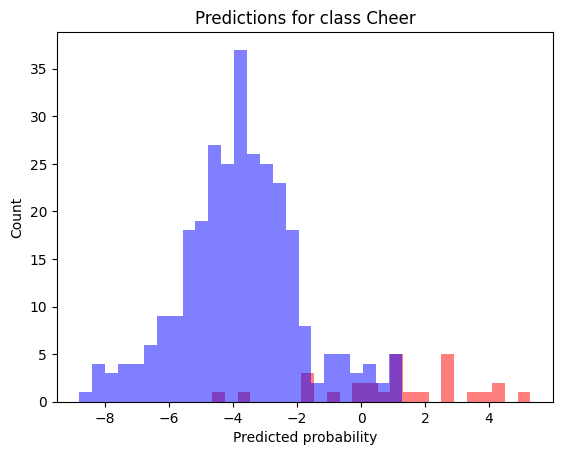

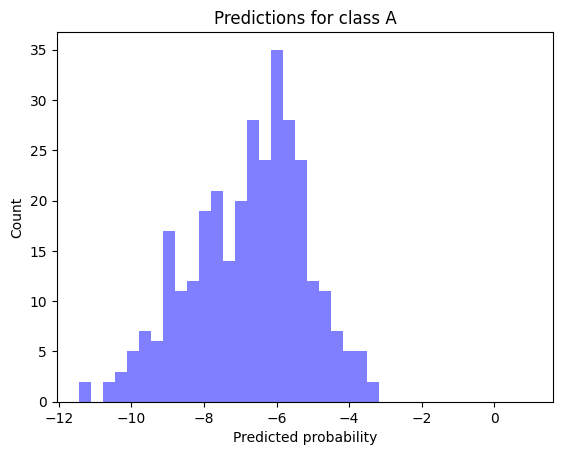

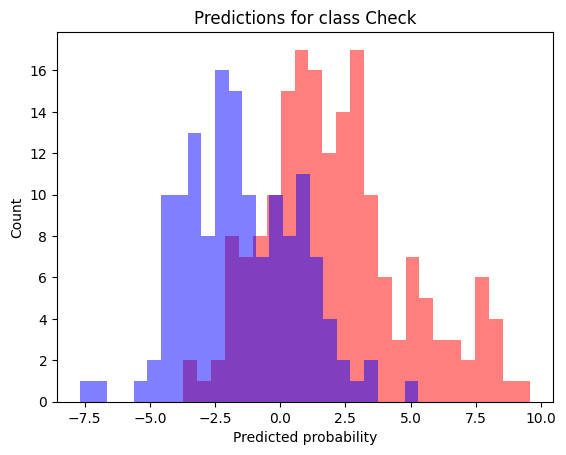

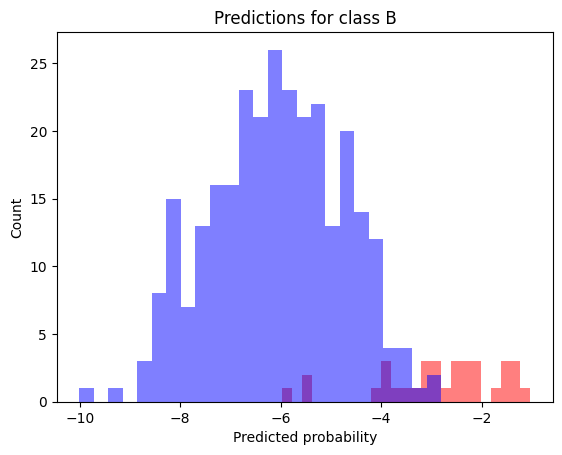

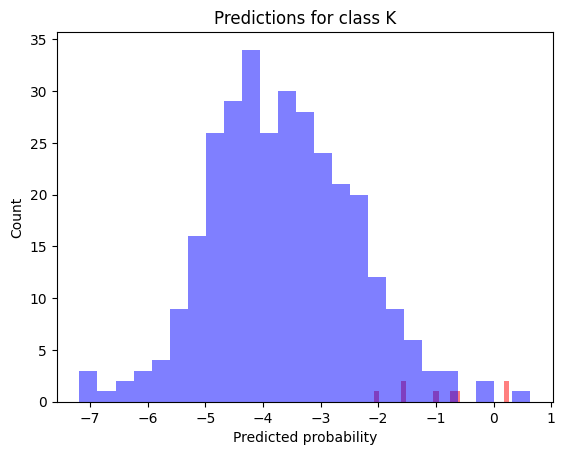

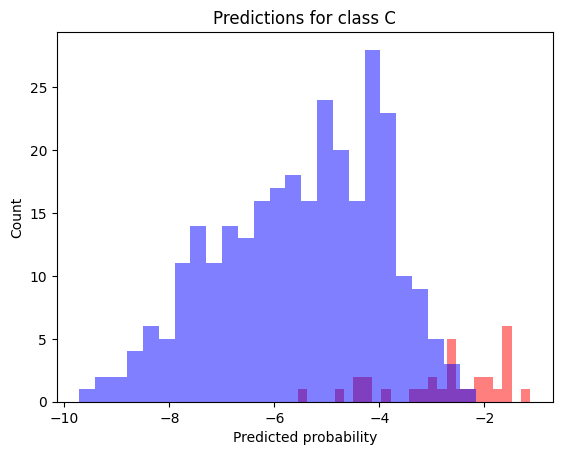

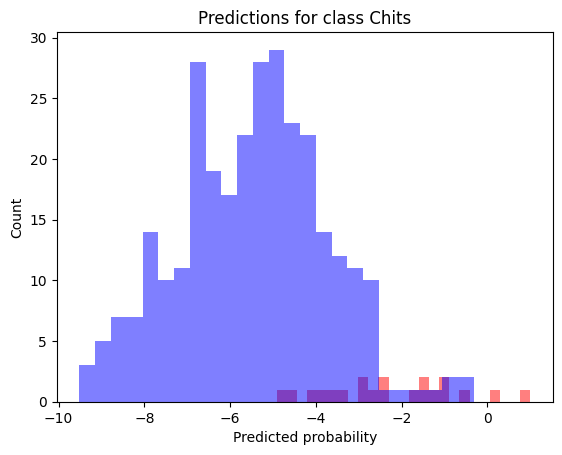

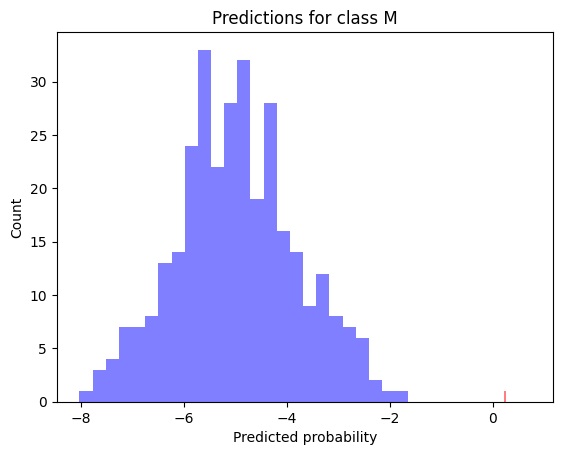

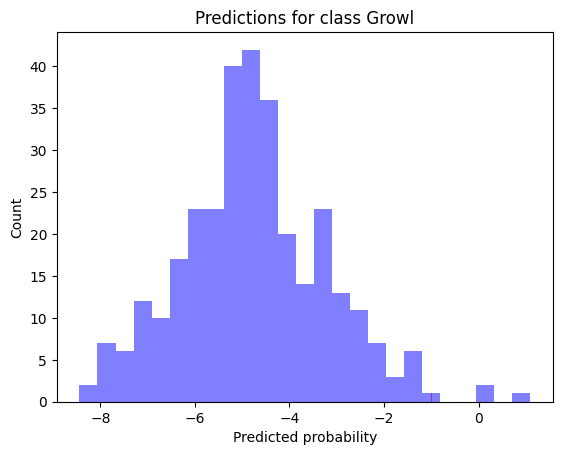

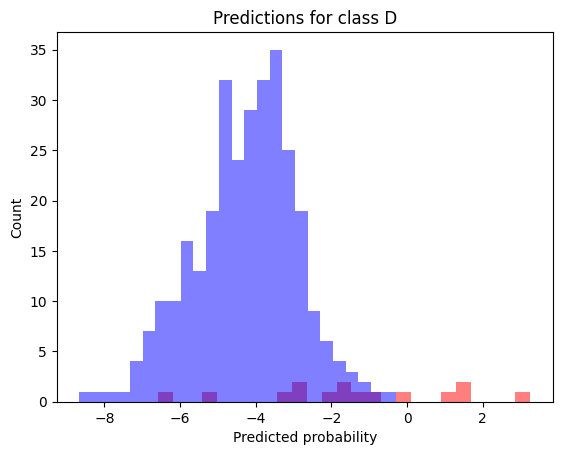

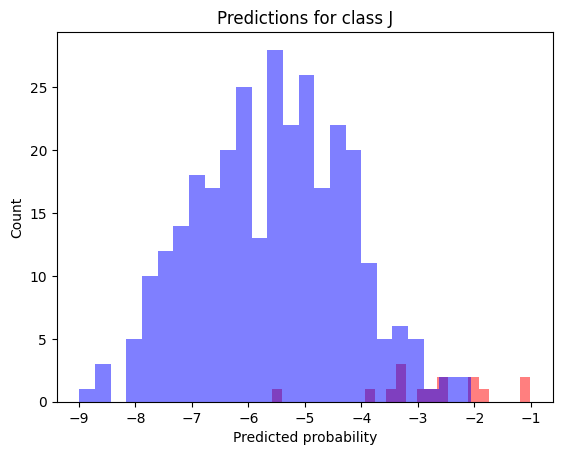

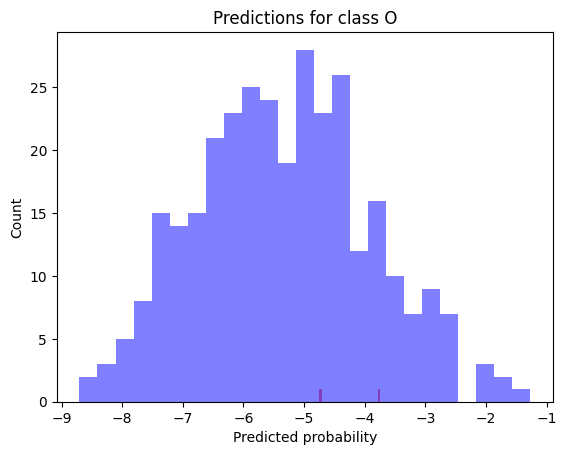

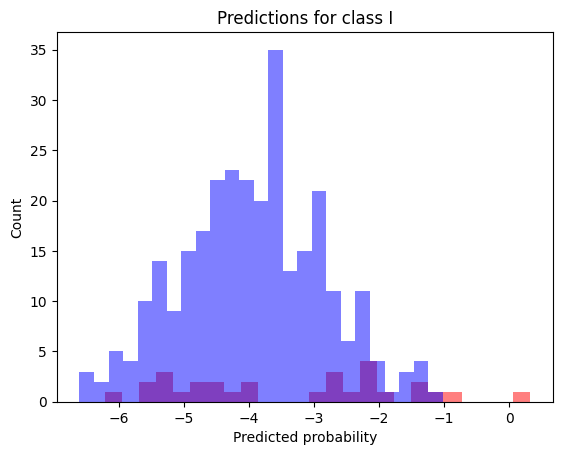

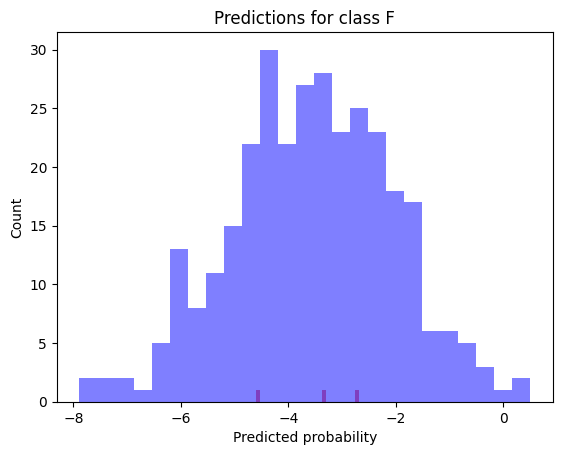

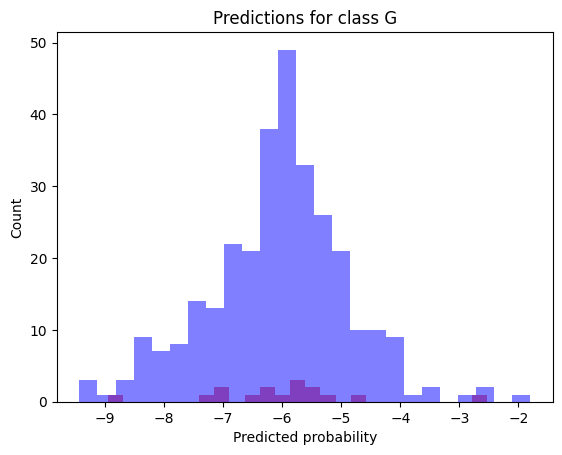

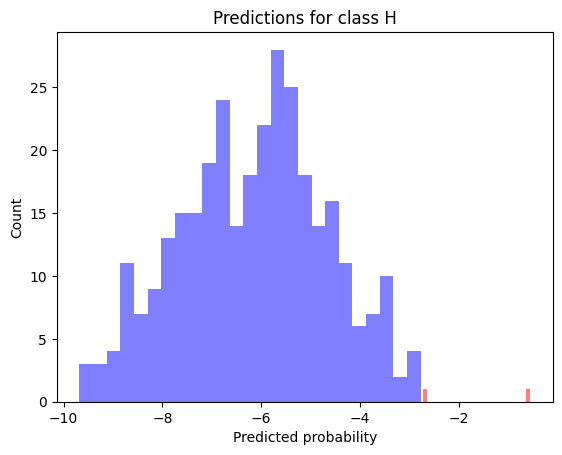

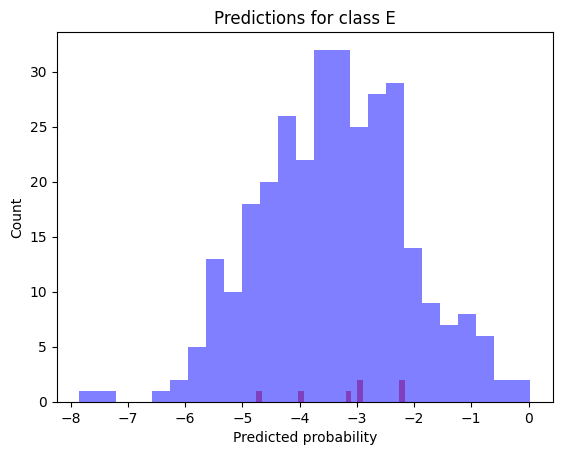

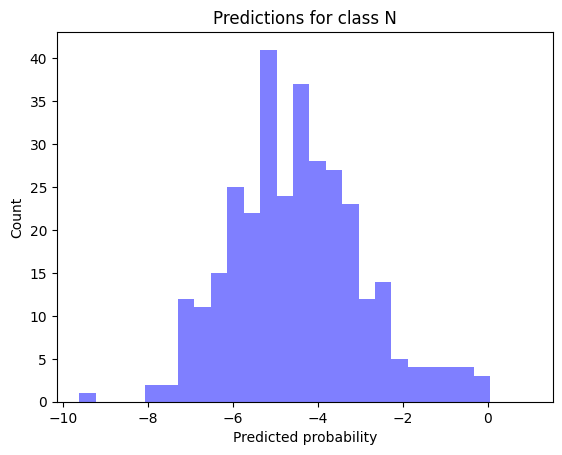

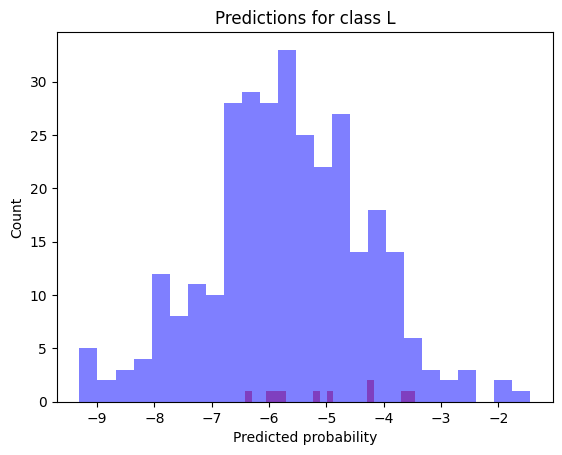

In [104]:
# make predictions by passing the embeddings through the classifier
preds = birdnet.network(torch.tensor(emb_val)).detach()

# plot the histograms for the 3 biggest classes

# plot histograms of predictions for the biggest classes
import matplotlib.pyplot as plt
for class_name in classes:
    class_idx = list(val_set.columns).index(class_name)
    plt.figure()
    positives = val_set.values[:, class_idx] == 1
    negatives = val_set.values[:, class_idx] == 0
    plt.hist(preds[positives, class_idx].numpy(), bins=25, color="red", alpha=0.5, label='Positive samples')
    plt.hist(preds[negatives, class_idx].numpy(), bins=25, color ="blue", alpha=0.5, label='Negative samples')
    plt.title(f"Predictions for class {class_name}")
    plt.xlabel("Predicted probability")
    plt.ylabel("Count")
    plt.show()

In [66]:
#can you write code for a classification report for each class?
from sklearn.metrics import classification_report
threshold = 0.5
pred_labels = (preds.numpy() >= threshold).astype(int)
report = classification_report(val_set.values, pred_labels, target_names=classes)
print(report)

              precision    recall  f1-score   support

       Cheer       0.67      0.64      0.65        28
           A       0.00      0.00      0.00         0
       Check       0.85      0.77      0.81       180
           B       0.00      0.00      0.00        34
           K       0.00      0.00      0.00         8
           C       1.00      0.19      0.32        31
       Chits       1.00      0.15      0.26        20
           M       0.00      0.00      0.00         1
       Growl       0.00      0.00      0.00         1
           D       1.00      0.27      0.42        15
           J       0.00      0.00      0.00        15
           O       0.00      0.00      0.00         2
           I       0.00      0.00      0.00        29
           F       0.00      0.00      0.00         3
           G       0.00      0.00      0.00        16
           H       0.00      0.00      0.00         2
           E       0.00      0.00      0.00         7
           N       0.00    

/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn

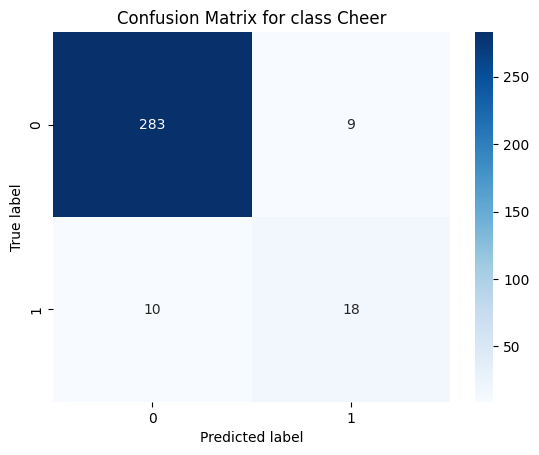

/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


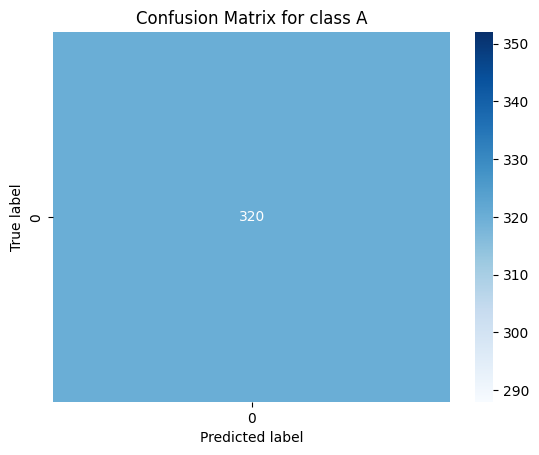

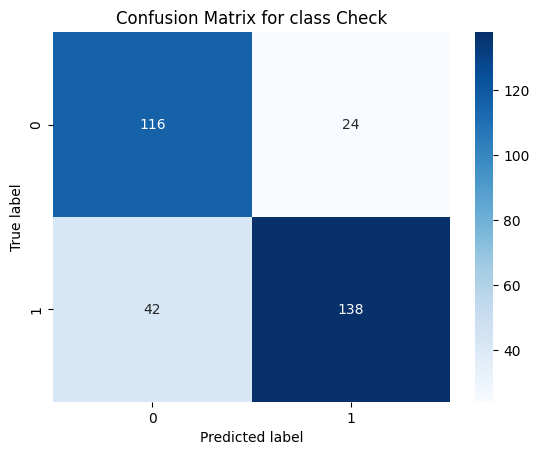

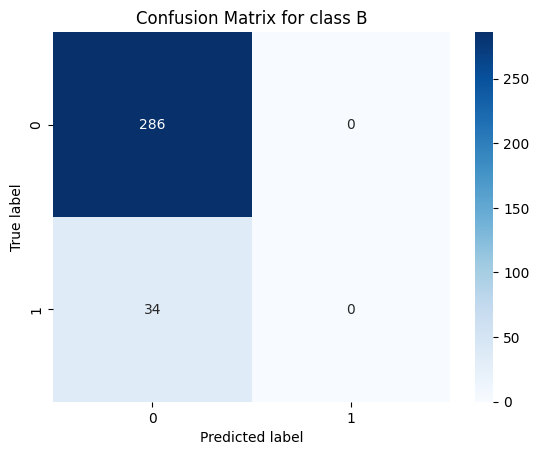

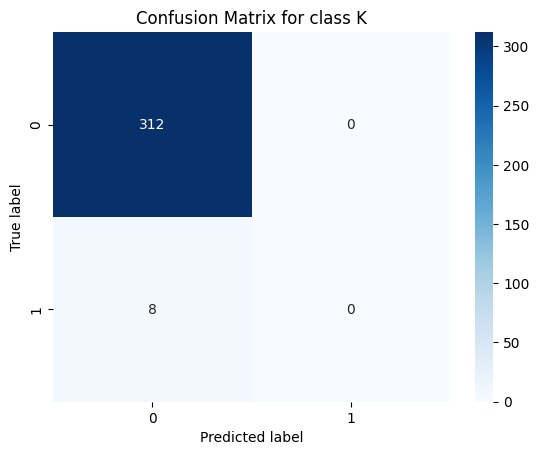

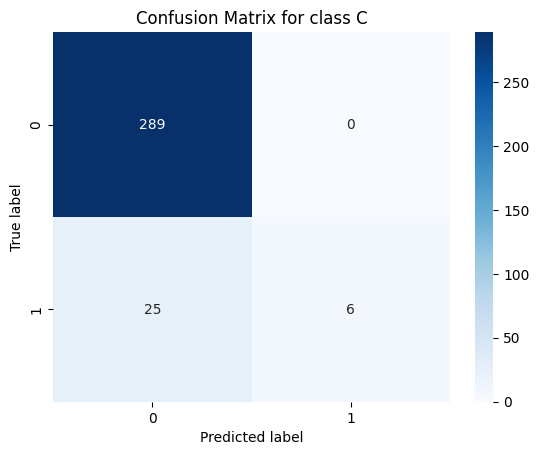

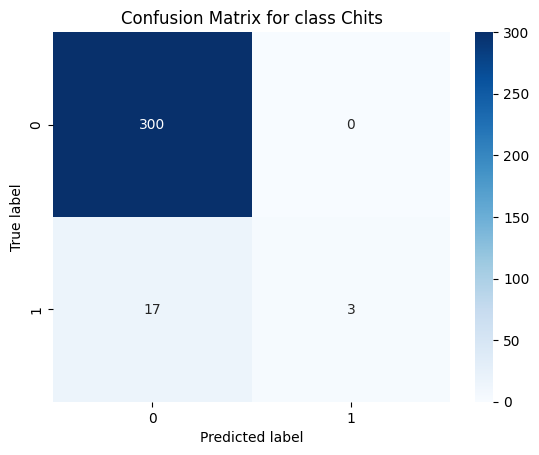

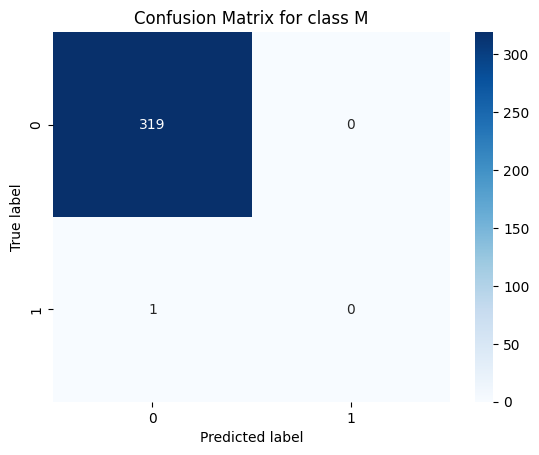

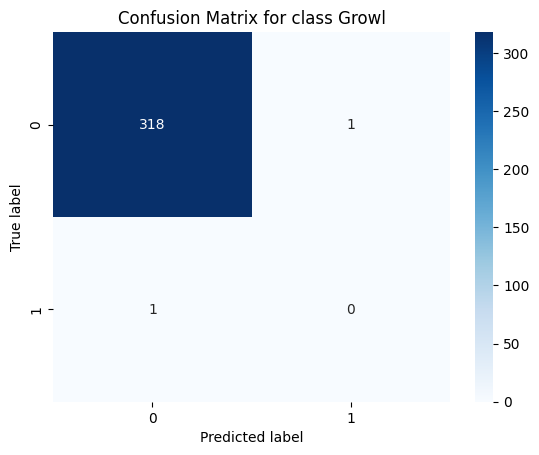

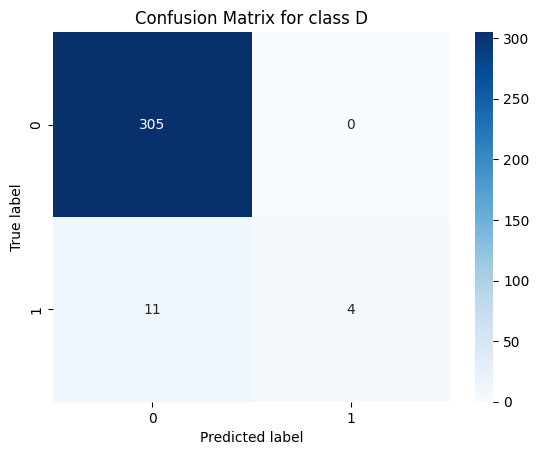

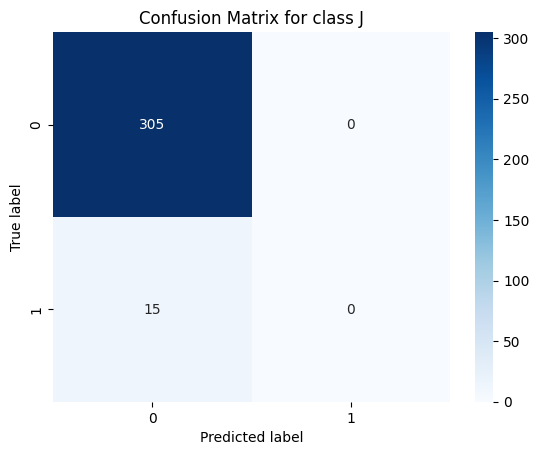

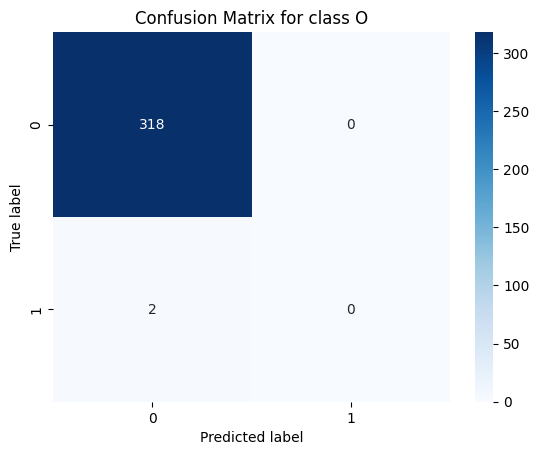

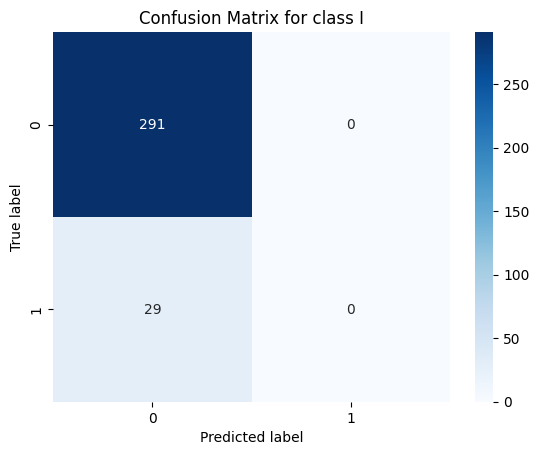

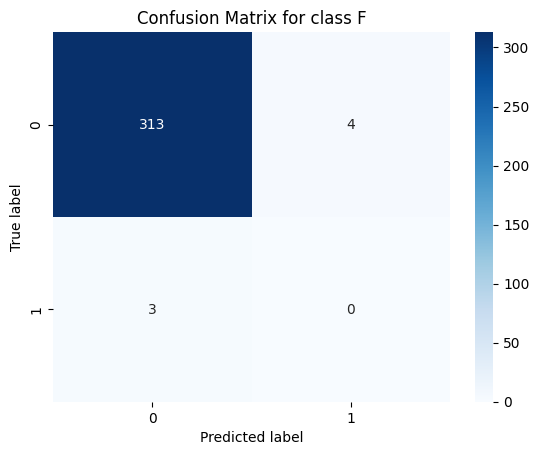

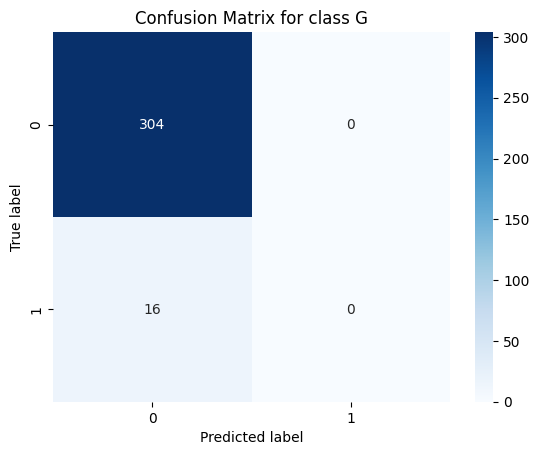

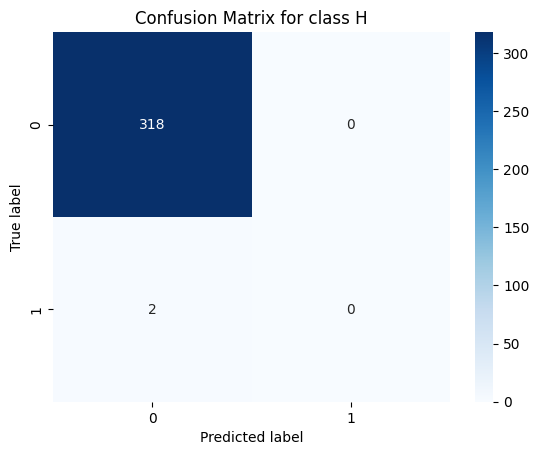

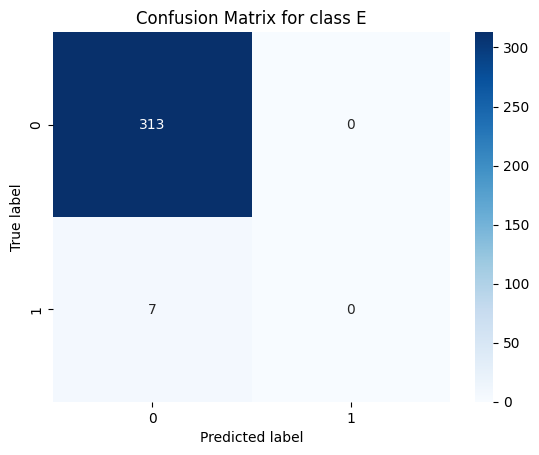

/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


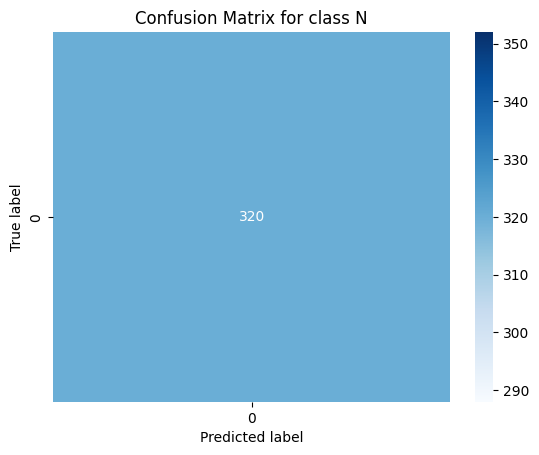

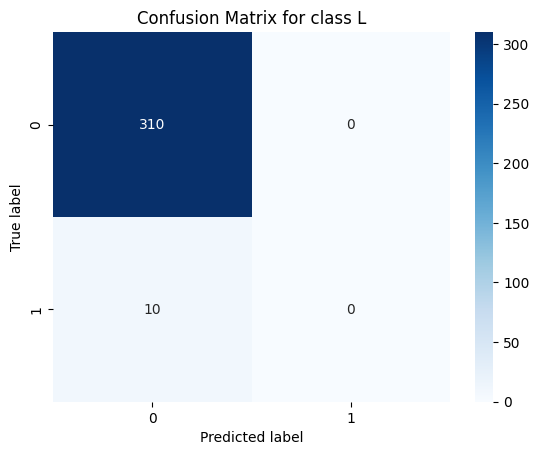

In [86]:
#visualize score distributions for each class mistaken as another class
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
biggest_classes

Cheer     28
A          0
Check    180
B         34
K          8
C         31
Chits     20
M          1
Growl      1
D         15
J         15
O          2
I         29
F          3
G         16
H          2
E          7
N          0
L         10
dtype: int64

Embedding the training samples 2 times with stochastic augmentation


  0%|          | 0/2 [00:00<?, ?it/s]

Embedding the validation samples


  0%|          | 0/3 [00:00<?, ?it/s]

Fitting the classifier
Epoch 100/1000, Loss: 0.048590533435344696, Val Loss: 0.3391634225845337
val AU ROC: nan
val MAP: 0.440


...

/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442:

Epoch 800/1000, Loss: 0.006808829959481955, Val Loss: 0.36765944957733154
val AU ROC: nan
val MAP: 0.423
Epoch 900/1000, Loss: 0.005741199944168329, Val Loss: 0.37249821424484253
val AU ROC: nan
val MAP: 0.422


/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442:

Epoch 1000/1000, Loss: 0.004929162096232176, Val Loss: 0.3772311210632324
val AU ROC: nan
val MAP: 0.421
Training complete


/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


Save the model

In [54]:
birdnet.save("/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/OpenSoundScape/blackbirdcallv1.model")

Code for loading the model later

In [ ]:
# reload the saved model later, perhaps in a different script or notebook:
loaded_model = bmz.BirdNET.load("./saved_custom_birdnet.model")

# use the model to make predictions on a dataframe or on a list of audio files
preds = loaded_model.predict(labels_val.head())